# House Price Prediction Project

## 1. Problem Statement
The objective of this project is to analyze factors affecting house prices and build a predictive model using machine learning techniques.

## 2. Data Understanding
The dataset contains various features such as crime rate, number of rooms, distance from facilities, environmental factors, and house prices. The target variable is 'price'.

In [1]:
import pandas as pd

In [2]:
df=pd.read_csv("House_Price.csv")

In [3]:
df.head()

,price,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,airport,n_hos_beds,n_hot_rooms,waterbody,rainfall,bus_ter,parks
0,24.0,0.00632,32.31,0.538,6.575,65.2,4.35,3.81,4.18,4.01,24.7,4.98,YES,5.480,11.1920,River,23,YES,0.049347
1,21.6,0.02731,37.07,0.469,6.421,78.9,4.99,4.70,5.12,5.06,22.2,9.14,NO,7.332,12.1728,Lake,42,YES,0.046146
2,34.7,0.02729,37.07,0.469,7.185,61.1,5.03,4.86,5.01,4.97,22.2,4.03,NO,7.394,101.1200,NaN,38,YES,0.045764
3,33.4,0.03237,32.18,0.458,6.998,45.8,6.21,5.93,6.16,5.96,21.3,2.94,YES,9.268,11.2672,Lake,45,YES,0.047151
4,36.2,0.06905,32.18,0.458,7.147,54.2,6.16,5.86,6.37,5.86,21.3,5.33,NO,8.824,11.2896,Lake,55,YES,0.039474


In [4]:
df.tail()

,price,crime_rate,resid_area,air_qual,room_num,age,dist1,dist2,dist3,dist4,teachers,poor_prop,airport,n_hos_beds,n_hot_rooms,waterbody,rainfall,bus_ter,parks
501,22.4,0.06263,41.93,0.573,6.593,69.1,2.64,2.45,2.76,2.06,19.0,9.67,NO,9.348,12.1792,Lake and River,27,YES,0.056006
502,20.6,0.04527,41.93,0.573,6.120,76.7,2.44,2.11,2.46,2.14,19.0,9.08,YES,6.612,13.1648,Lake and River,20,YES,0.059903
503,23.9,0.06076,41.93,0.573,6.976,91.0,2.34,2.06,2.29,1.98,19.0,5.64,NO,5.478,12.1912,NaN,31,YES,0.057572
504,22.0,0.10959,41.93,0.573,6.794,89.3,2.54,2.31,2.40,2.31,19.0,6.48,YES,7.940,15.1760,NaN,47,YES,0.060694
505,19.0,0.04741,41.93,0.573,6.030,80.8,2.72,2.24,2.64,2.42,19.0,7.88,YES,10.280,10.1520,NaN,45,YES,0.060336


In [5]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 19 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   price        506 non-null    float64
 1   crime_rate   506 non-null    float64
 2   resid_area   506 non-null    float64
 3   air_qual     506 non-null    float64
 4   room_num     506 non-null    float64
 5   age          506 non-null    float64
 6   dist1        506 non-null    float64
 7   dist2        506 non-null    float64
 8   dist3        506 non-null    float64
 9   dist4        506 non-null    float64
 10  teachers     506 non-null    float64
 11  poor_prop    506 non-null    float64
 12  airport      506 non-null    str    
 13  n_hos_beds   498 non-null    float64
 14  n_hot_rooms  506 non-null    float64
 15  waterbody    351 non-null    str    
 16  rainfall     506 non-null    int64  
 17  bus_ter      506 non-null    str    
 18  parks        506 non-null    float64
dtypes: float64(15), int

## 3. Data Cleaning
Missing values were handled, and categorical variables were converted into numerical format for analysis and modeling.

In [6]:
df.isnull().sum()

price            0
crime_rate       0
resid_area       0
air_qual         0
room_num         0
age              0
dist1            0
dist2            0
dist3            0
dist4            0
teachers         0
poor_prop        0
airport          0
n_hos_beds       8
n_hot_rooms      0
waterbody      155
rainfall         0
bus_ter          0
parks            0
dtype: int64

In [7]:
#MISSING VALUES 
df['n_hos_beds'] = df['n_hos_beds'].fillna(df['n_hos_beds'].median())
df['waterbody'] = df['waterbody'].fillna('None')

In [8]:
df.isnull().sum()

price          0
crime_rate     0
resid_area     0
air_qual       0
room_num       0
age            0
dist1          0
dist2          0
dist3          0
dist4          0
teachers       0
poor_prop      0
airport        0
n_hos_beds     0
n_hot_rooms    0
waterbody      0
rainfall       0
bus_ter        0
parks          0
dtype: int64

In [9]:
df.dtypes

price          float64
crime_rate     float64
resid_area     float64
air_qual       float64
room_num       float64
age            float64
dist1          float64
dist2          float64
dist3          float64
dist4          float64
teachers       float64
poor_prop      float64
airport            str
n_hos_beds     float64
n_hot_rooms    float64
waterbody          str
rainfall         int64
bus_ter            str
parks          float64
dtype: object

In [10]:
df['airport'] = df['airport'].astype('category')

In [11]:
print(df['airport'].dtype)

category


In [12]:
df['airport'] = df['airport'].map({'YES': 1, 'NO': 0})
df['bus_ter'] = df['bus_ter'].map({'YES': 1, 'NO': 0})

In [13]:
df = pd.get_dummies(df, columns=['waterbody'], drop_first=True)

## 4. Exploratory Data Analysis
EDA is performed to understand the distribution of variables and relationships between features.

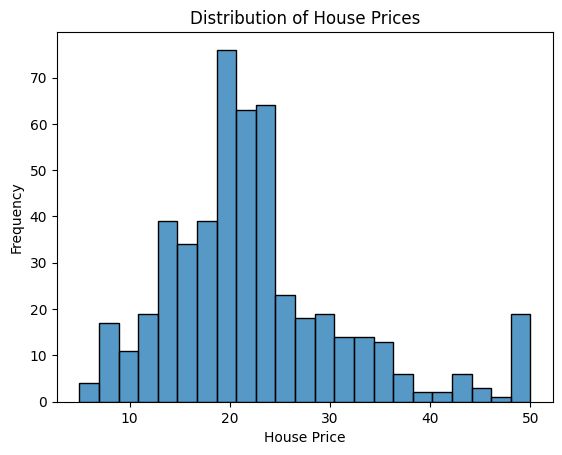

In [ ]:
#DATA VISUALIZATION
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df['price'])

plt.title("Distribution of House Prices")
plt.xlabel("House Price")
plt.ylabel("Frequency")

plt.show()

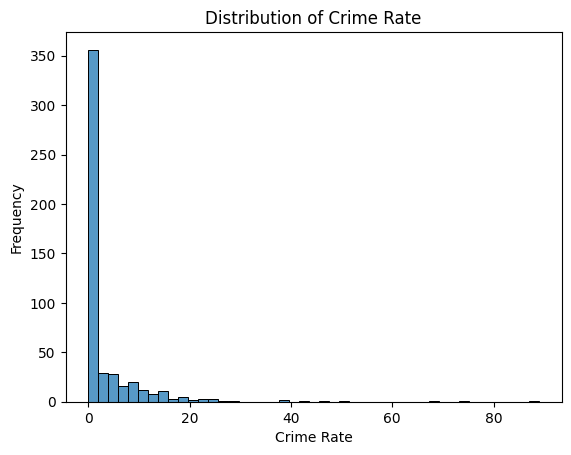

In [30]:
sns.histplot(df['crime_rate'])

plt.title("Distribution of Crime Rate")
plt.xlabel("Crime Rate")
plt.ylabel("Frequency")

plt.show()

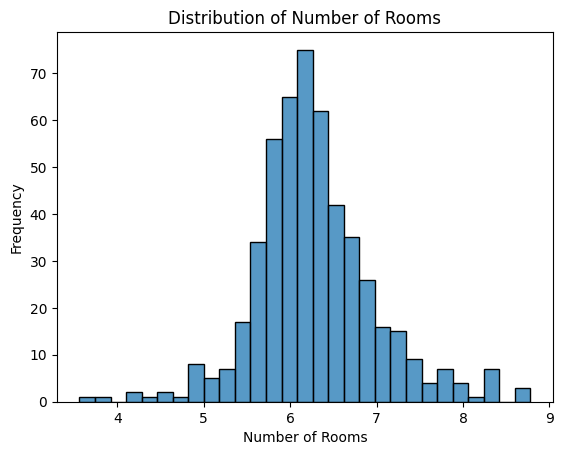

In [29]:
sns.histplot(x=df['room_num'])

plt.title("Distribution of Number of Rooms")
plt.xlabel("Number of Rooms")
plt.ylabel("Frequency")

plt.show()

In [17]:
df['airport'].value_counts()

airport
1    279
0    227
Name: count, dtype: int64

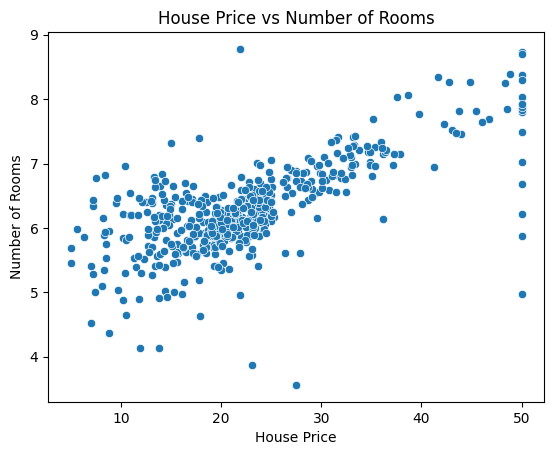

In [28]:
sns.scatterplot(x='price', y='room_num', data=df)

plt.title("House Price vs Number of Rooms")
plt.xlabel("House Price")
plt.ylabel("Number of Rooms")

plt.show()

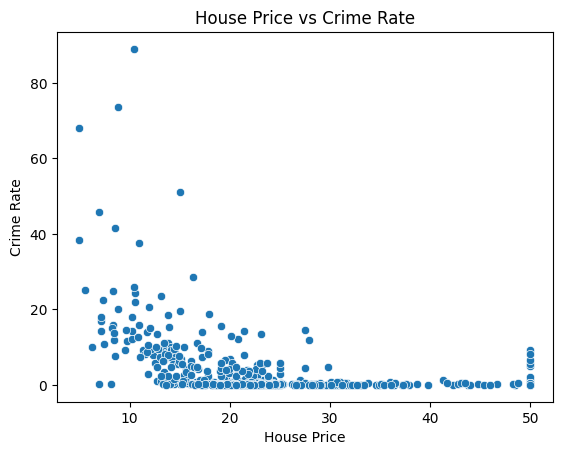

In [27]:
sns.scatterplot(x='price', y='crime_rate', data=df)

plt.title("House Price vs Crime Rate")
plt.xlabel("House Price")
plt.ylabel("Crime Rate")

plt.show()

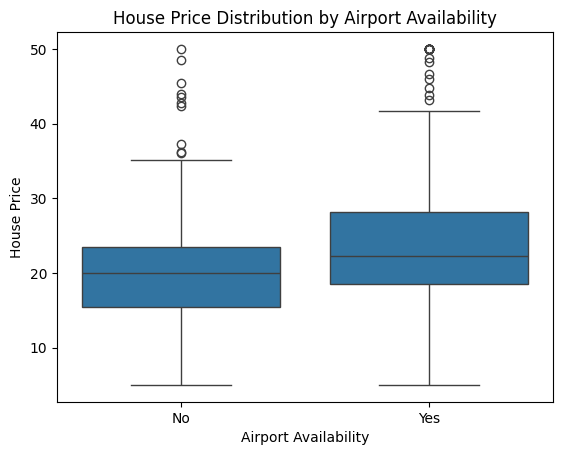

In [20]:
df['airport_label'] = df['airport'].map({1: 'Yes', 0: 'No'})

sns.boxplot(x='airport_label', y='price', data=df)
plt.title("House Price Distribution by Airport Availability")
plt.xlabel("Airport Availability")
plt.ylabel("House Price")
plt.show()

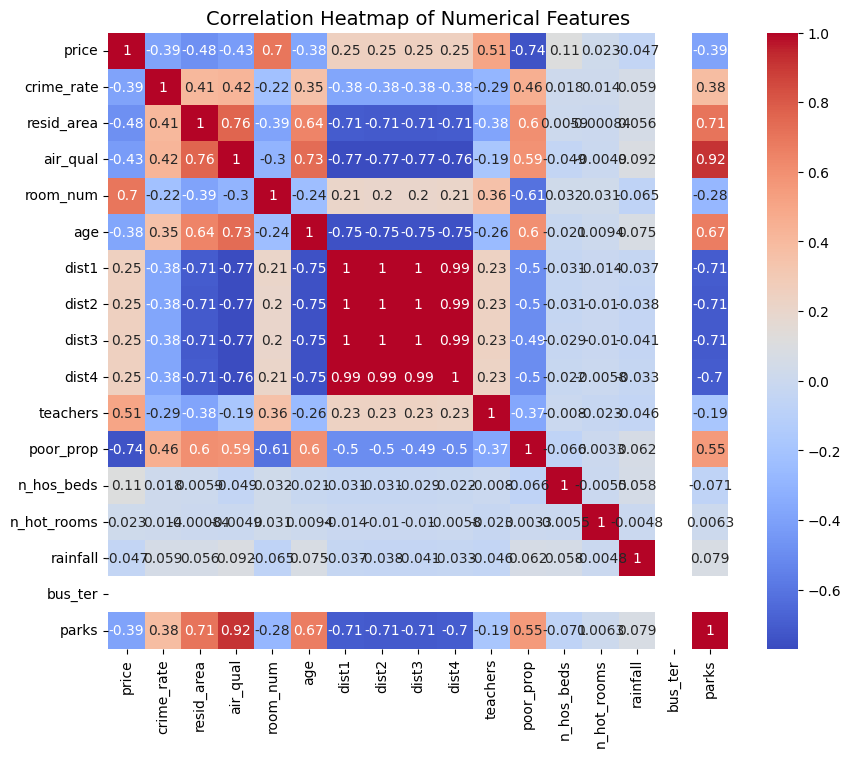

In [21]:
numeric_df = df.select_dtypes(include=['number'])

plt.figure(figsize=(10,8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap of Numerical Features", fontsize=14)
plt.show()

In [22]:
#ADDING A ROW
df['avg_dist'] = df[['dist1','dist2','dist3','dist4']].mean(axis=1)

In [23]:
print(df['avg_dist'])

0      4.0875
1      4.9675
2      4.9675
3      6.0650
4      6.0625
        ...  
501    2.4775
502    2.2875
503    2.1675
504    2.3900
505    2.5050
Name: avg_dist, Length: 506, dtype: float64


In [24]:
df.groupby('airport')['price'].mean()

airport
0    20.669163
1    24.041935
Name: price, dtype: float64

In [ ]:
print(df.groupby('air_qual')['parks'].median())

air_qual
0.385    0.033292
0.389    0.034688
0.392    0.040353
0.394    0.042192
0.398    0.042686
           ...   
0.713    0.065504
0.718    0.066391
0.740    0.071118
0.770    0.074891
0.871    0.080231
Name: parks, Length: 81, dtype: float64


In [ ]:
df['price'].max()

np.float64(50.0)

## 5. Key Insights
- House prices decrease as crime rate increases.
- Houses with more than 5 rooms tend to have higher prices.
- Availability of parks increases property value.
- Distance-related features influence pricing.
- Environmental factors like air quality affect house prices.


## 6. Model Building
A Linear Regression model is used to predict house prices.

In [ ]:
#simple predicting model
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [ ]:
df['airport'] = df['airport'].map({'YES': 1, 'NO': 0})
df['bus_ter'] = df['bus_ter'].map({'YES': 1, 'NO': 0})

In [ ]:
df = pd.get_dummies(df, columns=['waterbody'], drop_first=True)

In [ ]:
X = df.drop('price', axis=1)
y = df['price']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
model = LinearRegression()
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


## 7. Model Evaluation

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
from sklearn.metrics import r2_score, mean_squared_error

print(r2_score(y_test, y_pred))
print(mean_squared_error(y_test, y_pred))

0.6468901356802375
26.03982594706206


## 8. Prediction
The model predictions are compared with actual values.

In [ ]:
import pandas as pd

results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results.head()

,Actual,Predicted
173,23.6,31.216882
274,32.4,32.104442
491,13.6,17.381954
72,22.8,23.242169
452,16.1,16.175912


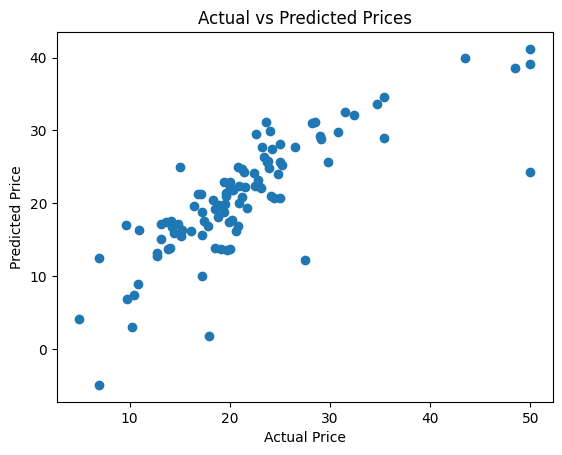

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

## 9. Conclusion
The analysis identified key factors affecting house prices such as number of rooms, crime rate, and environmental conditions. The Linear Regression model achieved moderate performance with an R² score of 0.64, demonstrating the ability to predict house prices based on input features.The Linear Regression model achieved an R² score of 0.64, indicating moderate predictive performance.